<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/05_01_%EA%B2%B0%EC%A0%95%ED%8A%B8%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MBC 마켓에서 신상품으로 캔 와인을 판매하고자 한다.
# 주류는 온라인 판매가 금지되어 있으므로, 온라인 예약 후 오프라인 매장 구매를 유도하려고 한다.

# 입고된 와인 상품을 확인해보니, 레드 와인인지 화이트 와인인지 구분되어 있지 않다.
# 캔에 인쇄된 알코올 도수, 당도, pH 값으로 와인 종류를 구분해보자.

# 품질을 확인하기 위해 개봉한 캔을 데이터로 활용한다. (로지스틱 회귀 모델을 적용한다.)

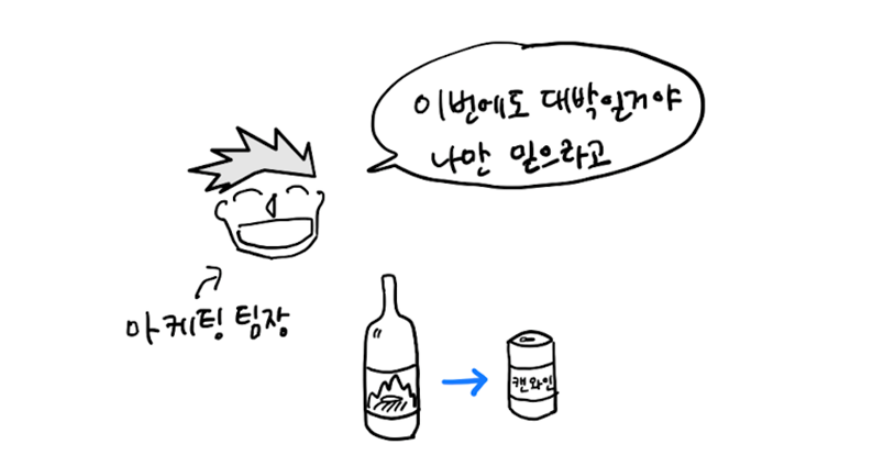

In [2]:
# 와인의 특성화된 데이터를 입력한다.
import pandas as pd

wine = pd.read_csv('https://bit.ly/wine_csv_data')
wine.head()
# 알코올, 당도, 산도, 클래스(타깃) → 0 : 레드 와인, 1: 화이트 와인

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
wine.info()

# 결과 : 6497개의 샘플, 4개의 열 (실수형)
# non-null : 누락된 값이 없는 상태

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [4]:
wine.describe() # 열에 대한 통계

# mean : 평균
# std : 표준편차
# min : 최소값

# 사분위수 :데이터를 순서대로 4등분한
# 25% : 1사분위
# 50% : 중간값 (2사분위)
# 75% : 3사분위
# 100% : 4사분위 (max)

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [5]:
# 'StandardScaler' 클래스로 특성을 표준화 해야한다.
data = wine[['alcohol', 'sugar', 'pH']].to_numpy() # 넘파이 배열로 변환한다.
# 와인 데이터 프레임 中 상위 3개의 열을 넘파이 배열로 변환하여 'data' 배열에 저장한다.

target = wine['class'].to_numpy() # 'class'열을 넘파이 배열로 변환하여 'target' 배열에 저장한다.

print(data) # 훈련을 위해 입력한 값

[[ 9.4   1.9   3.51]
 [ 9.8   2.6   3.2 ]
 [ 9.8   2.3   3.26]
 ...
 [ 9.4   1.2   2.99]
 [12.8   1.1   3.34]
 [11.8   0.8   3.26]]


In [6]:
print(target) # 훈련 정답

[0. 0. 0. ... 1. 1. 1.]


In [7]:
# 훈련 세트와 테스트 세트로 나눈다.
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size = 0.2, random_state = 42
)

# 'train_test_split' 함수는 값을 설정하지 않으면 자동으로 25%를 테스트 세트로 지정한다.
# 'test_size = 0.2'를 활용하여 20% 정도만 테스트 세트로 지정한다.

print(train_input.shape, test_input.shape) # 6496 * 0.8 = 5196.8

(5197, 3) (1300, 3)


In [13]:
from sklearn.preprocessing import StandardScaler # 훈련 세트 전처리 (단위를 맞추기 위해 표준 점수로 변환한다.)

ss = StandardScaler()
ss.fit(train_input) # 훈련을 시작한다.

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

print(train_scaled)
print('----------------------------------------')
print(test_scaled)

[[ 0.01376574  0.4646116  -0.16888369]
 [ 1.60871671 -0.70299854  0.26967864]
 [ 1.10504798 -0.70299854  1.20945505]
 ...
 [-0.82568214  0.0267578   0.14437512]
 [-0.82568214  0.52716215 -0.23153545]
 [-0.82568214 -0.57789745  1.83597265]]
----------------------------------------
[[ 1.44082714  1.52797084  0.26967864]
 [-0.48990299 -0.68214836  0.3323304 ]
 [ 1.27293756  0.40206106 -0.23153545]
 ...
 [ 1.60871671 -0.76554908 -0.16888369]
 [-0.90962693  0.88161523  0.52028568]
 [-1.49724045  2.09092573 -1.98578474]]


In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression() # 로지스틱 회귀 모델로 훈련한다.
lr.fit(train_scaled, train_target) # 훈련을 시작한다.

print(lr.score(train_scaled, train_target)) # 약 79.08%
print(lr.score(test_scaled, test_target)) # 약 77.76%

# 결과 : 80점 이하로, 점수가 낮게 도출되었다. (과소 적합)

0.7808350971714451
0.7776923076923077


In [15]:
# 제출용 보고서를 작성해보자.
print(lr.coef_, lr.intercept_) # 로지스틱 회귀 (계수 == 가중치, 절편 == 더해지는 값)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [16]:
# 1. 알코올 도수 값에 '0.51268071'을 곱한다.
# 2. 당도 값에 '1.67335441'을 곱한다.
# 3. pH 값에 '-0.68775646'을 곱한다.
# 4. 곱한 값을 모두 더한다.
# 5. 더한 값에 절편 값인 '1.81773456'을 더한다.
# 6. 위의 결과 값이 0보다 크면 화이트 와인, 작으면 레드 와인이라고 결론낸다.
# 현재 77% 정도의 정확도로 분류가 가능하다.

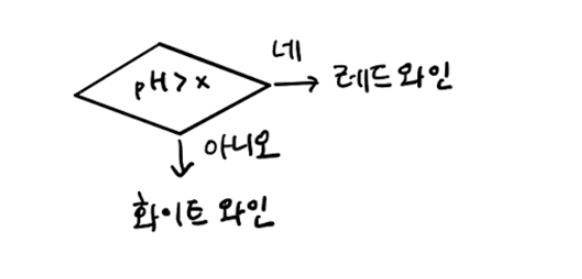

In [17]:
# 결정 트리 ('if'문과 유사하다.)
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state = 42)
dt.fit(train_scaled, train_target) # 훈련을 시작한다.

print(dt.score(train_scaled, train_target)) # 훈련 세트
print(dt.score(test_scaled, test_target)) # 테스트 세트

# 결과 : 훈련 점수 약 99.69%, 테스트 점수 약 85.92% (과대 적합)

0.996921300750433
0.8592307692307692


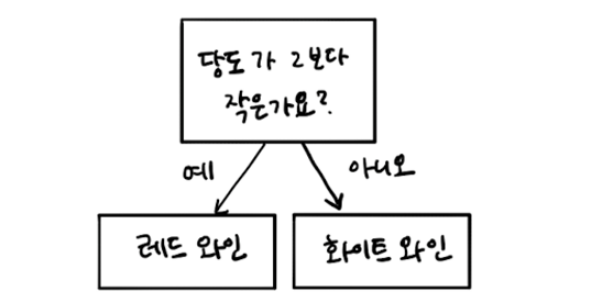

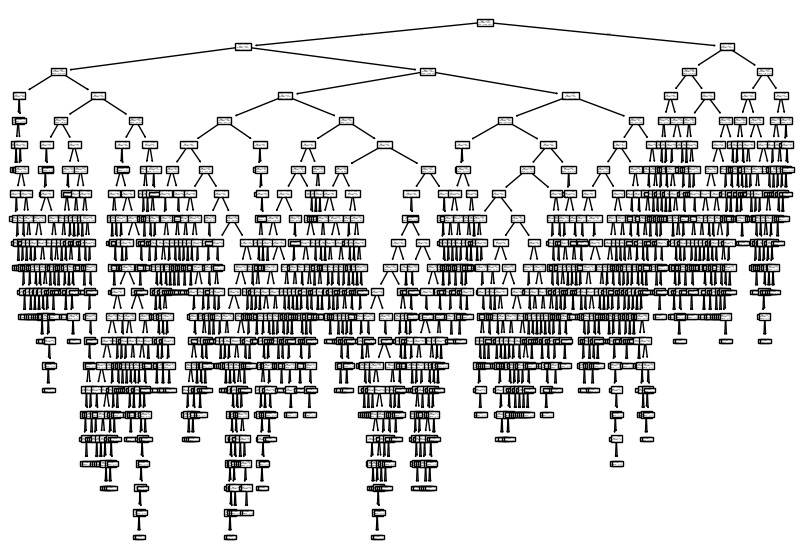

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (10, 7)) # figsize = (가로 인치, 세로 인치)
plot_tree(dt)
plt.show()

# 최상위 노드 : 루트 노드
# 최하위 노드 : 리프 노드

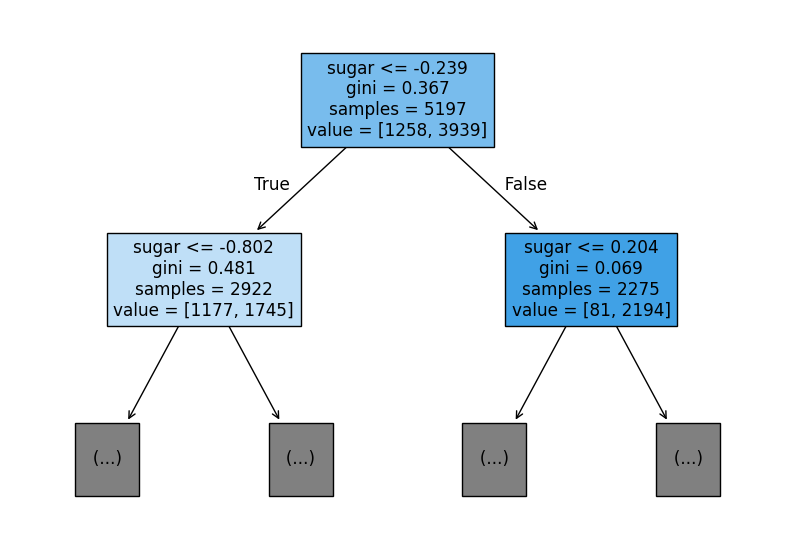

In [20]:
plt.figure(figsize = (10, 7))
plot_tree(dt, max_depth = 1, filled = True, feature_names = ['alcohol', 'sugar', 'pH'])
# max_depth = 1 : 루트 노드를 제외한다.
# filled = True : 클래스에 맞춰 색칠한다.
plt.show()
# 만약 'sugar'가 '-0.239'보다 크면 False
# 만약 'sugar'가 '-0.239'보다 같거나 작으면 True (왼쪽 가지로 향한다.)
# 총 샘플 개수 : 5,197개
# 음성 클래스(레드 와인) : 1,258개
# 양성 클래스(화이트 와인) : 3,939개

# 아래쪽 노드의 왼쪽 노드 : 음성 클래스 1,177개, 양성 클래스 1,745개
# 아래쪽 노드의 오른쪽 노드 : 음성 클래스 81개, 양성클래스 2,194개 → 대부분 화이트 와인 샘플이 이 노드로 이동되었다.

In [ ]:
# gini : 불순도를 의미하며, 노드에서 데이터를 분할할 기준을 정한다.

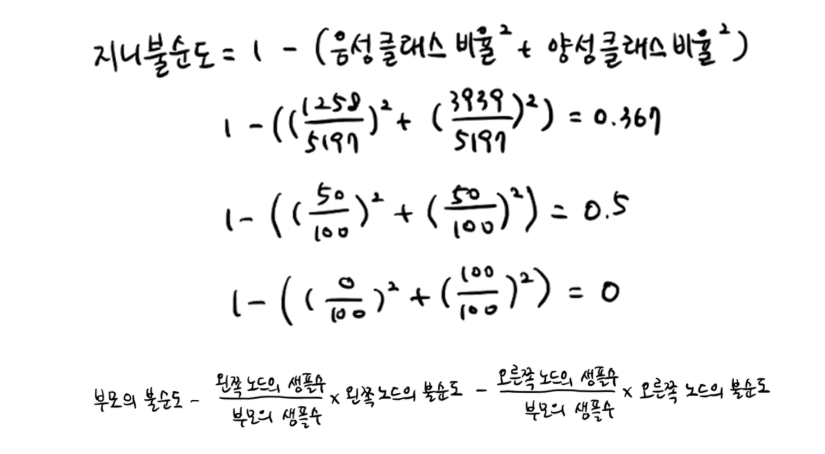

In [21]:
# 가지치기 : 트리의 깊이(depth)를 지정하여 트리를 정리한다.

# 새로운 객체의 깊이를 3으로 생성한다.
dt = DecisionTreeClassifier(max_depth = 3, random_state = 42) # 트리의 깊이 : 3
dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target)) # 약 84.54%
print(dt.score(test_scaled, test_target)) # 약 84.15%

0.8454877814123533
0.8415384615384616


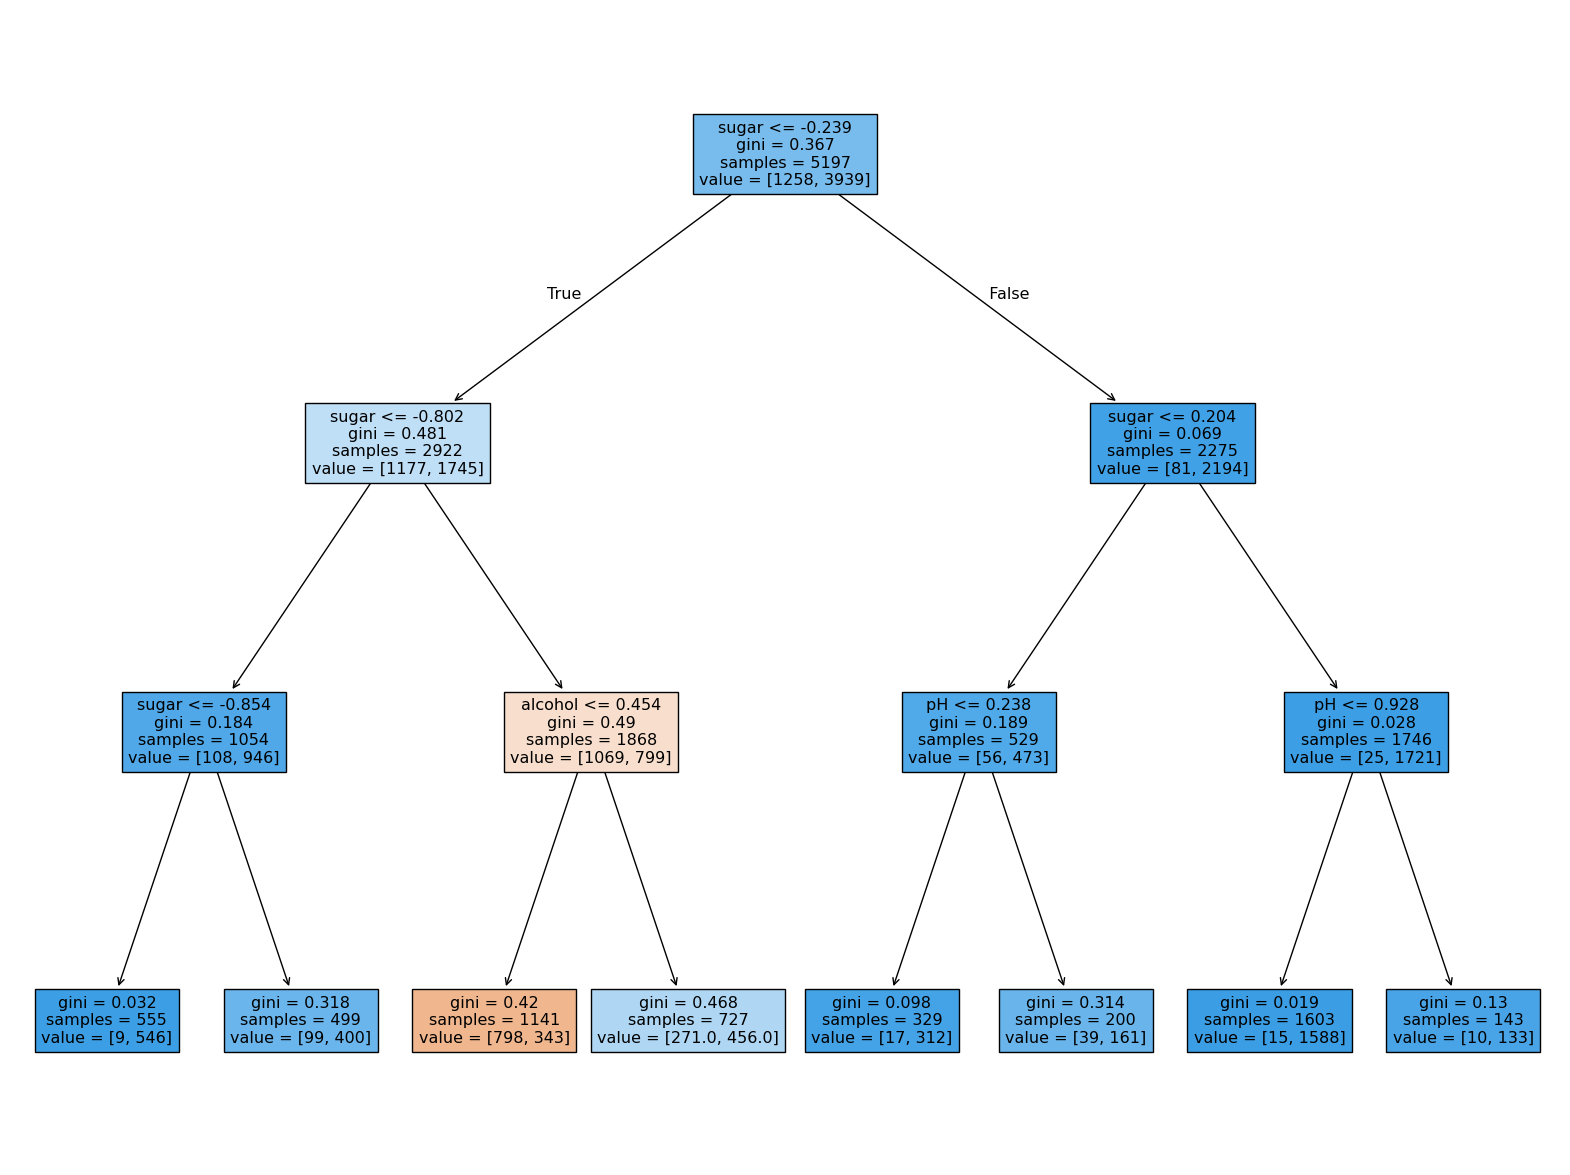

In [22]:
plt.figure(figsize = (20, 15))
plot_tree(dt, filled = True, feature_names = ['alcohol', 'sugar', 'pH'])
plt.show()

In [23]:
# 특성 값의 스케일은 효과가 없기 때문에, 표준화 (표준 점수) 전처리를 하지 않고 결정 트리를 사용해보자.
dt = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dt.fit(train_input, train_target)

print(dt.score(train_input, train_target))  # 약 84.52%
print(dt.score(test_input, test_target))    # 약 84.15%  (표준화 점수를 사용하지 않았다.)

0.8454877814123533
0.8415384615384616


In [24]:
import numpy as np

sample = np.array([9.5, 1.6, 3.17])
sample = sample.reshape(1, -1)

dt.predict(sample)

# 결과 : 화이트 와인으로 예측한다.

array([1.])

In [25]:
pred = dt.predict([[9.5,1.6,3.17]])

if pred[0] == 0 :
  print("Red Wine")

else :
    print("White Wine")

White Wine


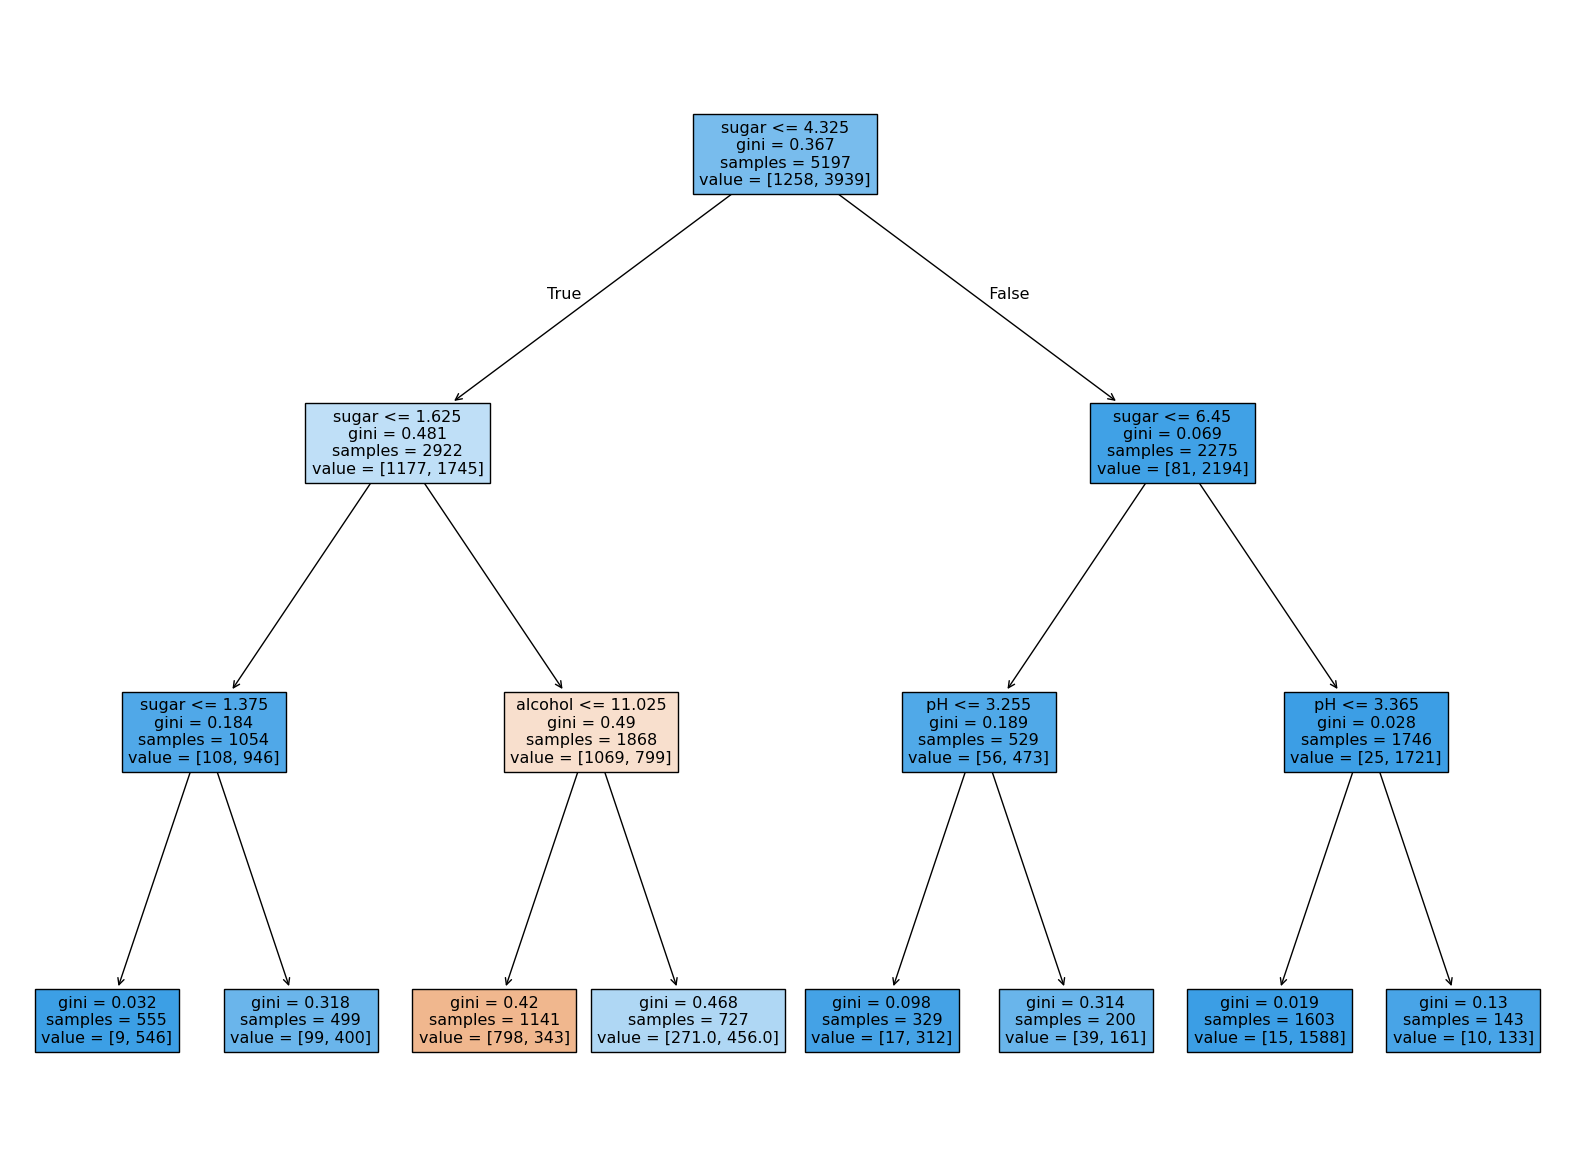

In [26]:
plt.figure(figsize = (20, 15))
plot_tree(dt, filled = True, feature_names = ['alcohol', 'sugar', 'pH'])
plt.show()

In [ ]:
# 결과 보고서에 입력할 내용 : 당도가 '1.625'보다 크고 '4.325'보다 작은 와인 중에, 알코올 도수가 '11.025'와 같거나 작으면 레드 와인으로 판단된다.
# 즉, 위의 트리에서 주황색 부분이 레드 와인이고, 나머지는 화이트와인이라고 판단된다.

In [27]:
# 결정 트리 : 어떤 특성이 가장 유용했는지 나타내는 특성 중요도를 계산해준다.
print(dt.feature_importances_)

# 결과 : [0.12345626 0.86862934 0.0079144 ] → 총계 : 1
#        알코올 도수    당도       pH

[0.12345626 0.86862934 0.0079144 ]


In [32]:
# 좌우가 균일하지 않은 트리
dt = DecisionTreeClassifier(min_impurity_decrease = 0.0005, random_state = 42) # min_impurity_decrease : 최소 불순도
dt.fit(train_input, train_target)

print(dt.score(train_input, train_target)) # 약 88.74%
print(dt.score(test_input, test_target)) # 약 88.15%

0.8874350586877044
0.8615384615384616


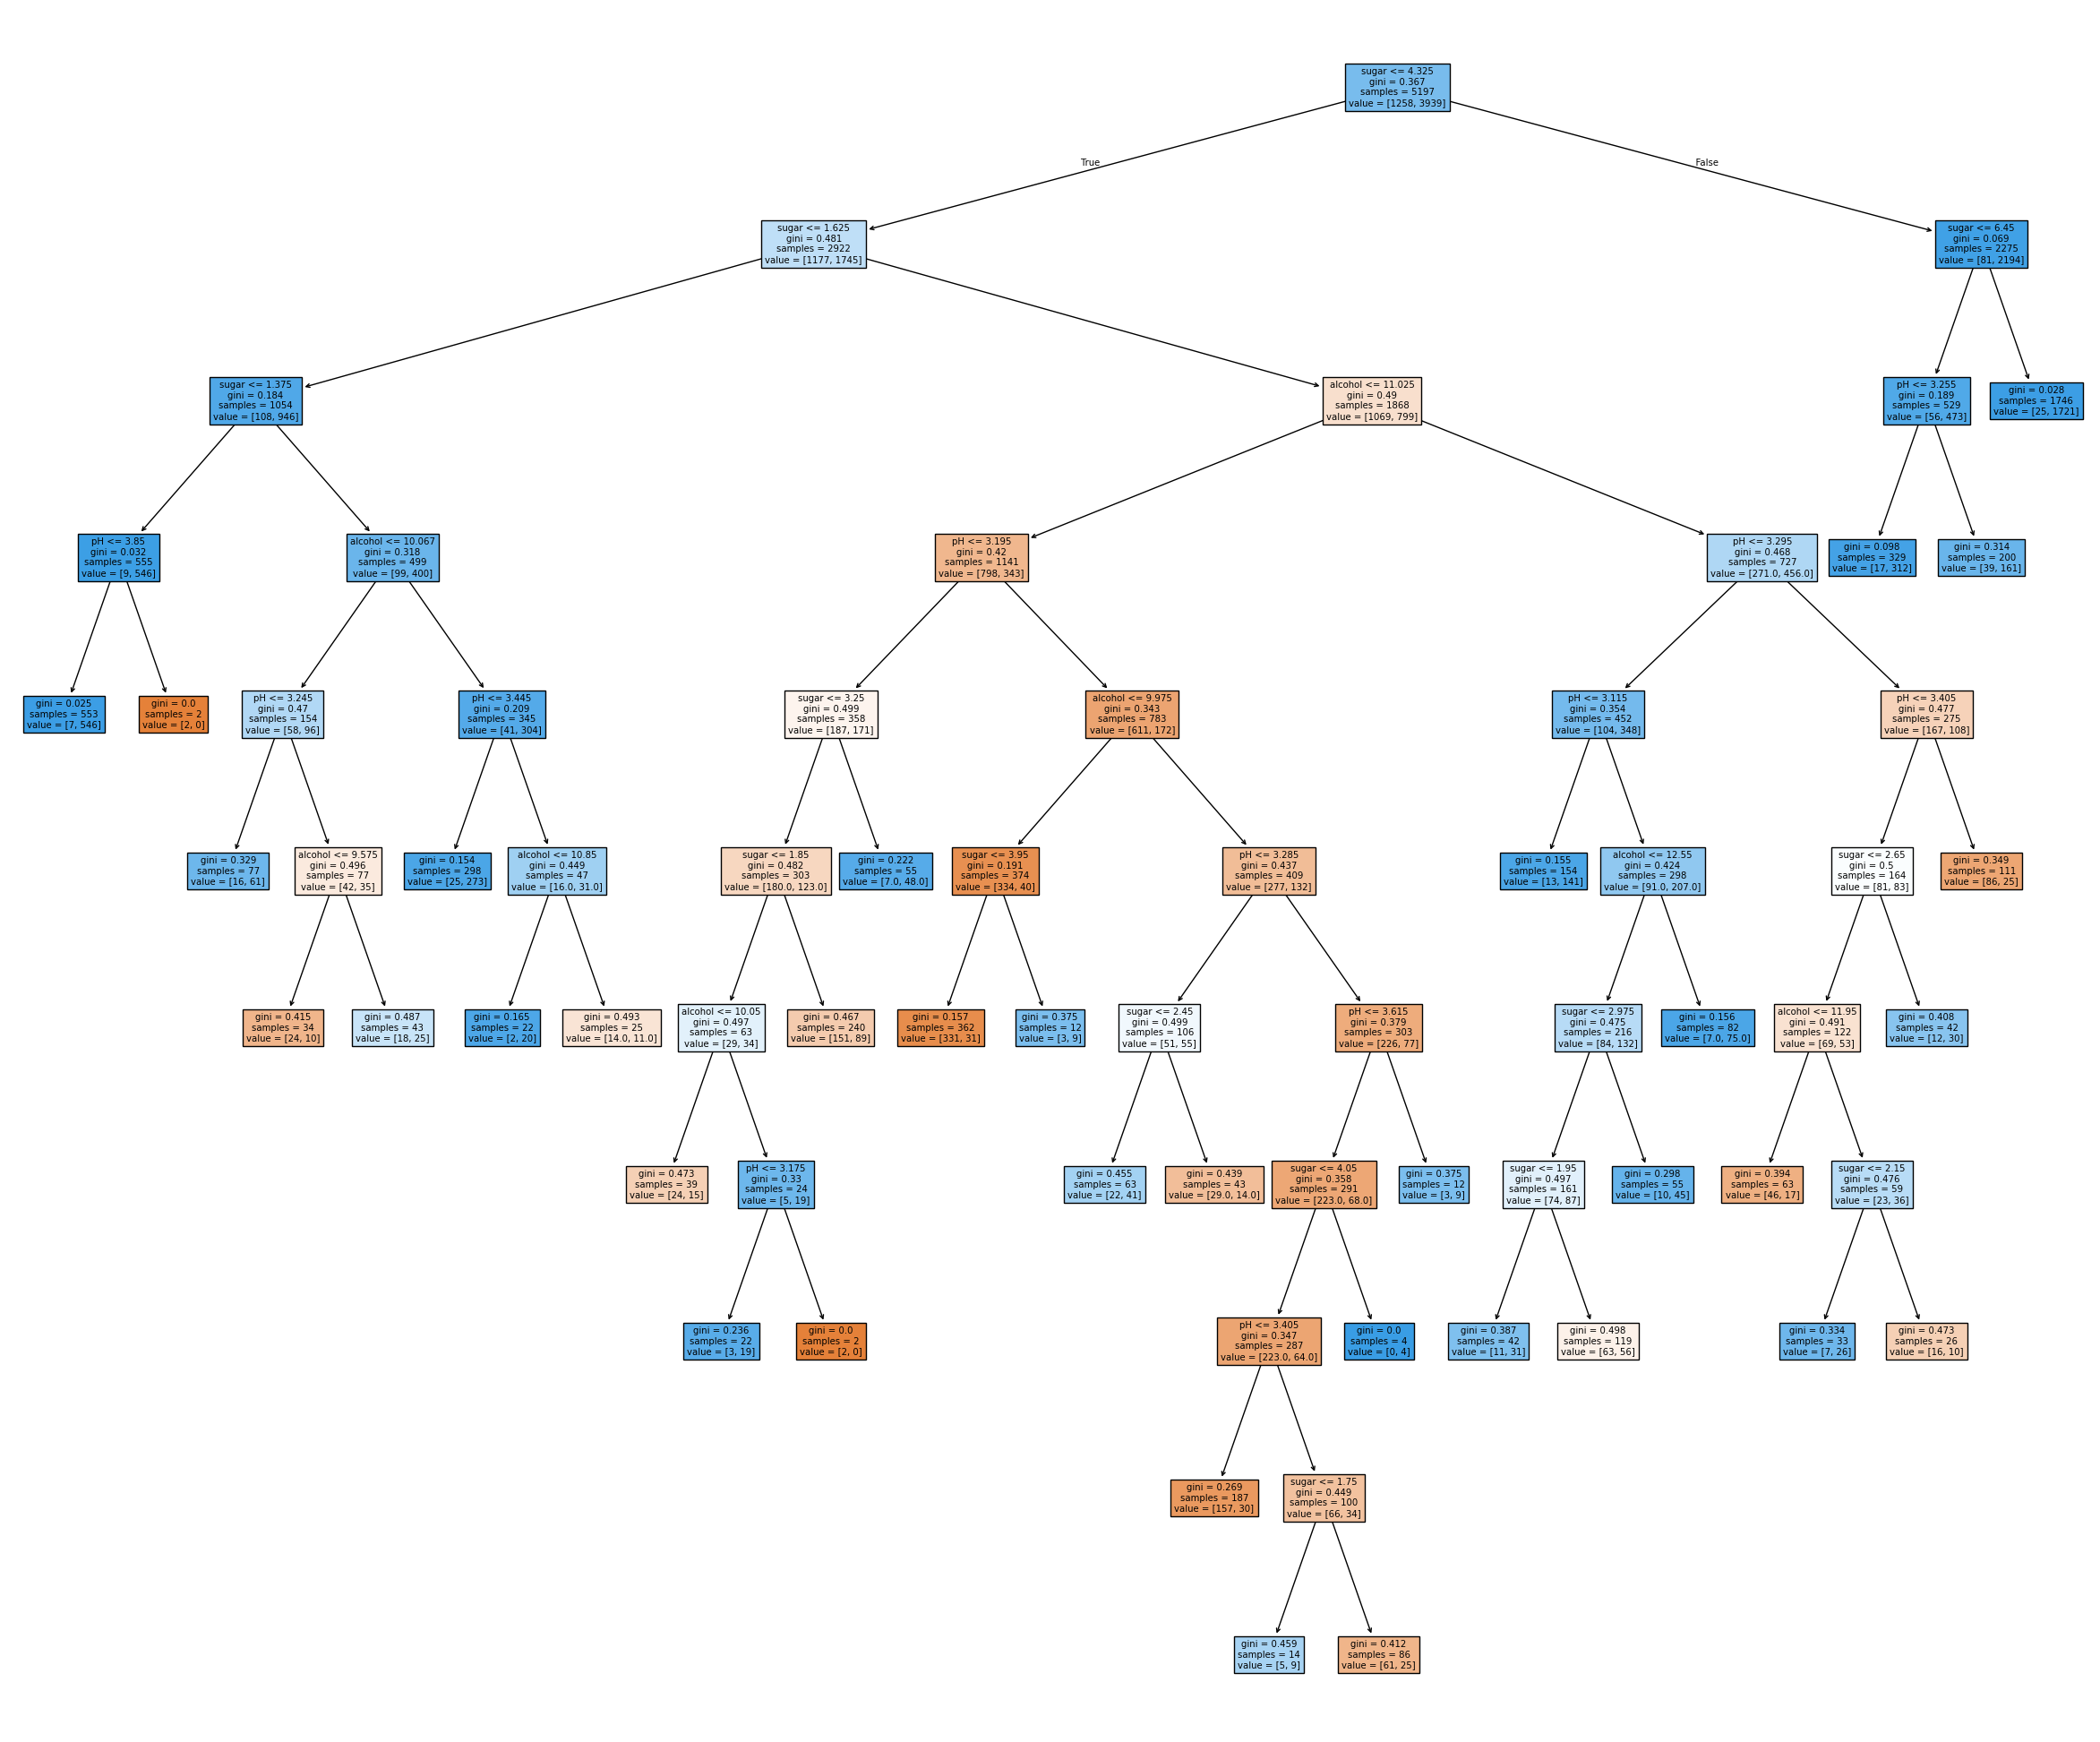

In [33]:
plt.figure(figsize=(30, 25))
plot_tree(dt, filled = True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()